# Problema 2
Para este problema, hay multiples secciones:
## Sección 1 - Creación de nube de datos
Consiste en crear 1000 datos, de forma aleatoria, para que fuera algo practico, me enfoque en 5 clusters, divididos en:
- Sección inferior izquierda
- Sección inferior derecha
- Sección superior derecha
- Sección superior izquierda
- Sección del centro
## Sección 2 - Implementación de Kmeans tradicional
Como nuestro problema parte de la modificación de kmeans, primero tenía que tener claro como implementar la versión tradicional para poder meter mano al algoritmo más complejo.  
Decidí utilizar centros aleatorios (aunque la primera versión de este programa fue con centros predifinidos, mandados como argumentos a la función)
## Sección 3 - Implementación de Kmeans con restricciones
Versión de Kmeans modificada, en esta sección estuve explorando multiples alternativas para la implementación del algoritmo, pero tuve algunos contratiempos entonces no concluí del todo. 
## Sección 4 - Pruebas de las funciones

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random

## S1 - Generando 5 clusters con distintas densidades 

In [2]:
# Generamos una nube de datos aleatoria
x1 = [random.randint(-100, random.randint(-80, -50)) for _ in range(250)]
y1 = [random.randint(-100, random.randint(-80, -50)) for _ in range(250)]

x2 = [random.randint(-100, random.randint(-80, -50)) for _ in range(250)]
y2 = [random.randint(random.randint(20,50),100) for _ in range(250)]

x3 = [random.randint(random.randint(20,70), 100) for _ in range(200)]
y3 = [random.randint(-100, random.randint(-30, -10)) for _ in range(200)]

x4 = [random.randint(random.randint(20,30), 100) for _ in range(200)]
y4 = [random.randint(random.randint(0,80), 100) for _ in range(200)]

x5 = [random.randint(random.randint(-25, 0), random.randint(0, 25)) for _ in range(100)]
y5 = [random.randint(random.randint(-25, 0), random.randint(0, 25)) for _ in range(100)]

df_x = x1+x2+x3+x4+x5
df_y = y1+y2+y3+y4+y5

## S2 - Implementación de Kmeans

In [3]:
# Implementación de kmeans tradicional
# Uso centros definidos por mi, para fácilitar pruebas y poder replicar el mismo ejemplo
def kmeans(x,y,k_clusters):
    clusters = {}
    cx = [random.randint(0, 999) for _ in range(k_clusters)]
    cy =[random.randint(0, 999) for _ in range(k_clusters)] 
    
    for k in range(k_clusters):
        cx[k] = x[cx[k]]
        cy[k] = y[cy[k]]
        clusters[k] = [[],[]]

    d_aux = 0.0
    delta_min = float('inf')
    k_aux = 0
    Ein_prev = 0.0
    
    for _ in range(100):
        Ein = 0.0
    
        # eliminamos todos los elementos de los clusters
        for k in clusters:
            clusters[k][0].clear()
            clusters[k][1].clear()
            
        for i in range(len(x)):
            for k in range(k_clusters):
                d_aux = np.sqrt((cx[k] - x[i])**2 + (cy[k] - y[i])**2)
        
                # Si la distancia calculada es menor que la menor previamente calculada, entonces será la nueva 
                # distancia menor
                if d_aux < delta_min:
                    delta_min = d_aux
                    k_aux = k
        
            clusters[k_aux][0].append(x[i])
            clusters[k_aux][1].append(y[i])
            
            d_aux = 0.0
            delta_min = float('inf')
            k_aux = 0
        
        # print(len(clusters[1]))
    
        for cluster in clusters:
            if len(clusters[cluster][0]) > 0:
                cx[cluster] = np.mean(clusters[cluster][0])
                cy[cluster] = np.mean(clusters[cluster][1])
                
        for cluster in clusters:
            for i in range( len(clusters[cluster][0]) ):
                #     Estoy calculando Ein = (xi - centroide(xi) + yi - centroide(yi) )**2, minimizamos la energía
                Ein += (clusters[cluster][0][i] - cx[cluster-1] + clusters[cluster][1][i] - cy[cluster-1])**2
        
        if abs(Ein - Ein_prev) < 0.000001:
            break
        Ein_prev = Ein
    return clusters, cx, cy

## S3 - Implementación de Kmeans modificado

In [4]:
# Funcion que evalua las restricciones y me devuelve los clusters validos
def eval_ml_cl(punto,g_ml,g_cl,clusters):
    c_validos = []
    if (punto in g_ml) and (punto in g_cl):
        for c_p in g_ml[punto]:
            if c_p in g_cl:
                raise ValueError("Reestricciones cruzadas, hay un punto en g_ml, y uno de sus pares esta en g_cl")

    if punto in g_ml:
        for k in clusters:
            for const in g_ml[punto]:
                if const in clusters[k][2]:
                    c_validos.append(k)

    if punto in g_cl:
        for k in c_validos:
            for const in g_cl[punto]:
                if const in clusters[k][2]:
                    c_validos.pop(k)

    return c_validos 
        
            
# Esta función crea una especie de diccionario, que utilizaré similar a una matriz de adjyacencia,
# ya que siento que es una forma mas sencilla de representar las restricciones que involucra a
# cada punto.
# Por ejemplo ml = [(1,2),(1,3),(1,4)] -> restricciones must-link
# grupos_ml= {1:[2,3,4], 2:[1], 3:[1], 4:[1]} -> esto es lo que espero generar. Similar con cl.
def grupos_preproc(ml,cl):
    grupos_ml = {}

    for res in ml:
        if res in cl:
            raise ValueError("No pueden haber 2 restricciones must/cannot link iguales")

        if res[0] in grupos_ml:
            if res[1] not in grupos_ml[res[0]]:
                grupos_ml[res[0]].append(res[1])
        else:
            grupos_ml[res[0]] = [res[1]]

        if res[1] in grupos_ml:
            if res[0] not in grupos_ml[res[1]]:
                grupos_ml[res[1]].append(res[0])
        else:
            grupos_ml[res[1]] = [res[0]]

    grupos_cl = {}

    for res in cl:
        if res[0] in grupos_cl:
            if res[1] not in grupos_cl[res[0]]:
                grupos_cl[res[0]].append(res[1])
        else:
            grupos_cl[res[0]] = [res[1]]

        if res[1] in grupos_cl:
            if res[0] not in grupos_cl[res[1]]:
                grupos_cl[res[1]].append(res[0])
        else:
            grupos_cl[res[1]] = [res[0]]


    return grupos_ml,grupos_cl
                
def constrainded_capacity_kmeans(x,y,cx,cy,k_clusters,constraints):
    clusters = {}
    clusters_validos = []
    d_x_c= []
    grupos_ml, grupos_cl = grupos_preproc(constraints["ml"],constraints["cl"])

    for k in range(k_clusters):
        #             [[componentes x], [componentes y], [indice respecto a D]]
        clusters[k] = [[],[],[]]

    d_aux = 0.0
    d_min = float('inf')
    k_aux = 0
    Ein_prev = 0.0

    ml_cl = []
    
    for _ in range(100):
        Ein = 0.0
        cons_i = 0
        map_to_class = {}
    
        # eliminamos todos los elementos de los clusters y restablecemos la prioridad
        for k in clusters:
            clusters[k][0].clear()
            clusters[k][1].clear()
            d_x_c.clear()
            
        for i in range(len(x)):
            # Guardamos todas las distancias hacia los clusters
            for k in range(k_clusters):
                d_x_c.append( np.sqrt((cx[k] - x[i])**2 + (cy[k] - y[i])**2) )

            clusters_validos = eval_ml_cl(i,grupos_ml,grupos_cl,clusters)

            if constraits["c"] == True:
                for c in clusters_validos:
                    if len(cluster[c][0]) > constraits["c"][1]:
                        continue
                    elif len(cluster[c][0]) <= constraits["c"][1]:
                        clusters[c][0].append(x[i])
                        clusters[c][1].append(y[i])
                        clusters[c][2].append(i)
            
            clusters[0][0].append(x[i])
            clusters[0][1].append(y[i])
            clusters[0][2].append(i)
            
            d_aux = 0.0
            delta_min = float('inf')
            k_aux = 0
    
        for cluster in clusters:
            if len(clusters[cluster][0]) > 0:
                cx[cluster] = np.mean(clusters[cluster][0])
                cy[cluster] = np.mean(clusters[cluster][1])
                
        for cluster in clusters:
            for i in range( len(clusters[cluster][0]) ):
                #     Estoy calculando Ein = (xi - centroide(xi) + yi - centroide(yi) )**2, minimizamos la energía
                Ein += (clusters[cluster][0][i] - cx[cluster-1] + clusters[cluster][1][i] - cy[cluster-1])**2
        
        if abs(Ein - Ein_prev) < 0.000001:
            break
        Ein_prev = Ein
    return clusters

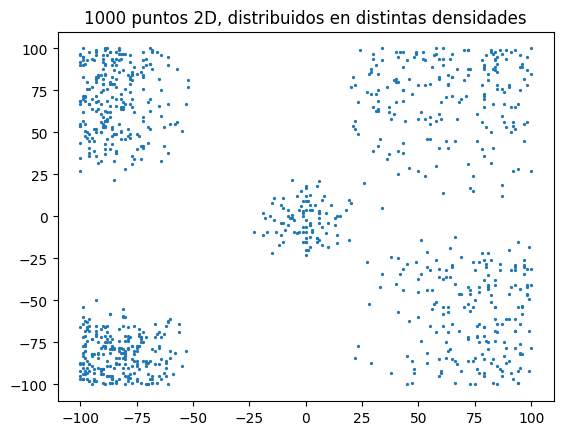

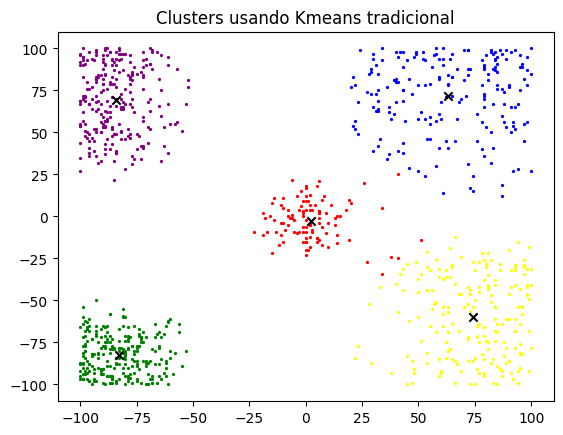

In [5]:
x = df_x
y = df_y

k_clusters = 5

# plt.scatter(cx,cy,marker="x",color="red")
plt.scatter(x,y,marker=".",s=7)
plt.title("1000 puntos 2D, distribuidos en distintas densidades")
plt.show()

# Como los centroides iniciales son aleatorios, a veces estos se acumulan en un solo cluster
clusters,cx,cy = kmeans(x,y,k_clusters)

# Gráficamos cada cluster
color= ["red","green","yellow","purple","blue"]
for k in range(k_clusters):
    plt.scatter(clusters[k][0],clusters[k][1],marker=".",s=7,color=color[k])

# Gráficamos cada centroide
plt.scatter(cx,cy,marker="x",color="black")
plt.title("Clusters usando Kmeans tradicional")

plt.show()

In [ ]:
# Probaremos la versión con restricciones
df = pd.read_csv("2d_points.csv")
x = df["x"]
y = df["y"]

k_clusters = 5

constraints = {
    "ml" : False, #Restricción must-link -> lista de listas de pares que deben estar juntos
    "cl" : False,  #Restricción cannot-link -> lista de listas de pares que no deben estar juntos
    "b"  : False, #Restricción balance -> valor en porcentaje de cantidad de datos por cluster
    "c"  : False  #Restricción capacidad -> tupla con valor minimo y máximo por cluster
}